# EDA & Missing-Value Handling

Reads data from the `ml_features` view (`sql/views.sql`, already filtered to
`data_source='historical'`) — base columns only, no dashboard aggregates.

Checklist:
- [x] `loan_status` distribution (baseline: 21.8% default rate on historical data)
- [x] Systematic leakage scan across every categorical column (default-rate spread) and
      every numeric-categorical pair (within-group variance ratio) — not just the two
      columns already under suspicion
- [x] `loan_grade` vs. default correlation — if the A vs. G gap exceeds ~90%, document the leakage decision in the model section
- [x] `loan_int_rate` missing pattern: random, or does it follow `loan_grade`?
- [x] Confirm no `person_age` values > 100 remain after `clean_outliers()`
- [x] Compare distributions before/after imputation

In [1]:
import pandas as pd
from sqlalchemy import text
import sys
sys.path.insert(0, '../etl')
from config import get_engine

engine = get_engine()
df = pd.read_sql(text("SELECT * FROM ml_features"), engine)
df.head()

,loan_id,client_id,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,debt_to_income_ratio,loan_status,age,...,credit_utilization_ratio,past_delinquencies,country,loan_term_months,other_debt,gender,marital_status,education_level,employment_type,open_accounts
0,4,CUST_00001,PERSONAL,D,35000.0,16.02,0.59,0.7356,1,22,...,0.4956,0,Canada,36,8402.45,Male,Married,High School,Self-employed,14
1,5,CUST_00002,EDUCATION,B,1000.0,11.14,0.10,0.2716,0,21,...,0.5854,3,Canada,36,1607.80,Female,Divorced,Master,Full-time,10
2,6,CUST_00003,MEDICAL,C,5500.0,12.87,0.57,0.8605,1,25,...,0.7507,0,UK,36,2760.51,Female,Married,Master,Full-time,14
3,7,CUST_00004,MEDICAL,C,35000.0,15.23,0.53,0.6436,1,23,...,0.3793,0,Canada,12,7155.29,Male,Married,Bachelor,Part-time,15
4,8,CUST_00005,MEDICAL,C,35000.0,14.27,0.55,0.9306,1,24,...,0.2281,0,USA,36,15626.15,Female,Single,Bachelor,Part-time,4


In [2]:
print("Rows, columns:", df.shape)
print("\nDtypes:\n", df.dtypes)
na_counts = df.isna().sum()
print("\nMissing values in the Postgres feature view:\n", na_counts[na_counts > 0] if na_counts.sum() else "none")

Rows, columns: (32581, 25)

Dtypes:
 loan_id                       int64
client_id                       str
loan_intent                     str
loan_grade                      str
loan_amnt                   float64
loan_int_rate               float64
loan_percent_income         float64
debt_to_income_ratio        float64
loan_status                   int64
age                           int64
income                      float64
home_ownership                  str
emp_length                  float64
default_on_file                 str
cred_hist_length              int64
credit_utilization_ratio    float64
past_delinquencies            int64
country                         str
loan_term_months              int64
other_debt                  float64
gender                          str
marital_status                  str
education_level                 str
employment_type                 str
open_accounts                 int64
dtype: object

Missing values in the Postgres feature view:
 no

## Why there's no missingness left in Postgres

`historical_load.py::impute_missing` already median-imputes `person_emp_length` and
`loan_int_rate` before the ETL inserts rows, so the feature view above has zero nulls.
To check whether the *original* missingness was random (MCAR) or followed a pattern
(MAR), the next cells go back to the raw source file, before imputation.

In [3]:
raw = pd.read_excel('../data/Credit_Risk_Dataset.xlsx')
na_raw = raw.isna().sum()
na_raw[na_raw > 0]

person_emp_length     895
loan_int_rate        3116
dtype: int64

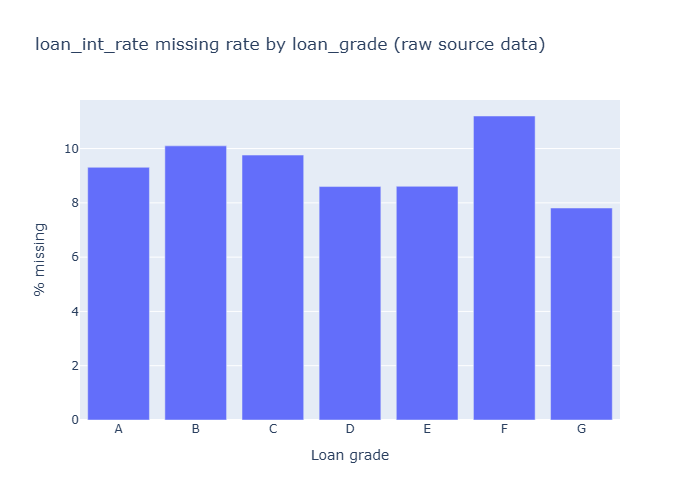

,loan_grade,pct_missing
0,A,9.31
1,B,10.10
2,C,9.76
3,D,8.60
4,E,8.61
5,F,11.20
6,G,7.81


In [4]:
import plotly.express as px
import plotly.io as pio

# Render figures as static PNGs instead of embedding a full interactive Plotly spec
# per chart. The interactive JSON was ~1.9MB of this notebook's ~2.4MB on disk, which
# makes the file slow to load and its diffs unreadable. Set before the first .show()
# so it applies to every figure below. Needs kaleido (already a dev dependency);
# fig.write_image() in the figure-export cell is unaffected either way.
pio.renderers.default = "png"

missing_rate_by_grade = (raw.groupby('loan_grade')['loan_int_rate']
                          .apply(lambda s: s.isna().mean() * 100)
                          .round(2)
                          .reset_index(name='pct_missing'))

fig_missing_rate = px.bar(
    missing_rate_by_grade, x='loan_grade', y='pct_missing',
    title='loan_int_rate missing rate by loan_grade (raw source data)',
    labels={'pct_missing': '% missing', 'loan_grade': 'Loan grade'},
)
fig_missing_rate.show()
missing_rate_by_grade

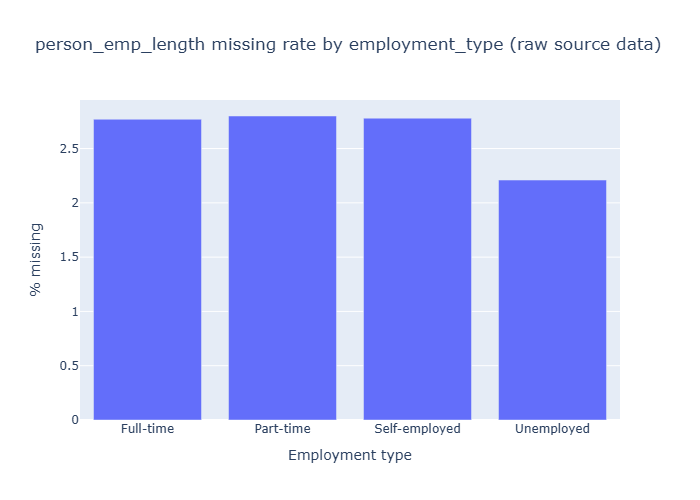

,employment_type,pct_missing
0,Full-time,2.77
1,Part-time,2.80
2,Self-employed,2.78
3,Unemployed,2.21


In [5]:
missing_emp_by_type = (raw.groupby('employment_type')['person_emp_length']
                        .apply(lambda s: s.isna().mean() * 100)
                        .round(2)
                        .reset_index(name='pct_missing'))

fig_missing_emp = px.bar(
    missing_emp_by_type, x='employment_type', y='pct_missing',
    title='person_emp_length missing rate by employment_type (raw source data)',
    labels={'pct_missing': '% missing', 'employment_type': 'Employment type'},
)
fig_missing_emp.show()
missing_emp_by_type

**Finding**: `loan_int_rate` missingness ranges 7.8-11.2% across grades A-G, and
`person_emp_length` missingness ranges 2.2-2.8% across employment types, both without a
clear trend (`Unemployed` is not the highest, contrary to the intuitive guess). Neither
column's missingness tracks the variable most likely to explain it — consistent with
**MCAR (missing completely at random)** rather than a grade- or employment-driven
pattern. Median imputation (already applied in the ETL) is a reasonable choice here.

## `loan_status` distribution

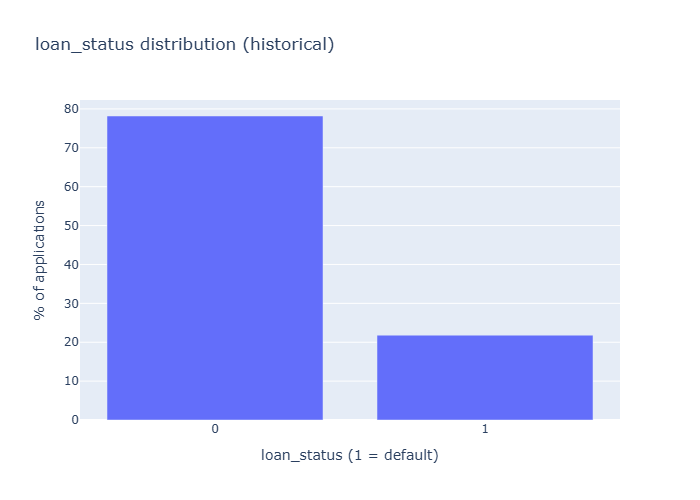

,loan_status,pct
0,0,78.18
1,1,21.82


In [6]:
status_pct = (df['loan_status'].value_counts(normalize=True) * 100).round(2)
status_df = pd.DataFrame({'loan_status': status_pct.index.astype(str), 'pct': status_pct.values})

fig_status = px.bar(
    status_df, x='loan_status', y='pct',
    title='loan_status distribution (historical)',
    labels={'pct': '% of applications', 'loan_status': 'loan_status (1 = default)'},
)
fig_status.show()
status_df

## Systematic leakage scan (method, not just the two columns already under suspicion)

Two general techniques, applied to **every** feature column instead of a hand-picked few,
so the method would surface a leaky column even without already knowing to look for one.

The column lists below are derived from **dtype at runtime**, not hardcoded. That matters:
the first version of this scan hardcoded 5 categorical columns, and when `ml_features`
later grew from 18 to 25 columns, the 7 new ones were never scanned at all - the notebook
kept reporting on the old list with no warning. Deriving from dtype means any column added
to the view in future is picked up automatically.

1. **Per-category default rate spread**: for every categorical column, compute
   `loan_status` mean per group. A spread that stretches toward the 0%/100% extremes
   (near-total separation) is the leakage signal - a legitimate risk factor nudges the
   rate, it doesn't split it almost perfectly.
2. **Within-group variance ratio**: for every categorical column, check how much a
   numeric column's variance shrinks once grouped by it (`within-group variance /
   overall variance`). A ratio near 0 means the numeric column is close to
   deterministic given the category - the two are encoding the same information twice.

scanning 22 feature columns (9 categorical + 13 numeric)
categorical: ['loan_intent', 'loan_grade', 'home_ownership', 'default_on_file', 'country', 'gender', 'marital_status', 'education_level', 'employment_type']
numeric    : ['loan_amnt', 'loan_int_rate', 'loan_percent_income', 'debt_to_income_ratio', 'age', 'income', 'emp_length', 'cred_hist_length', 'credit_utilization_ratio', 'past_delinquencies', 'loan_term_months', 'other_debt', 'open_accounts']


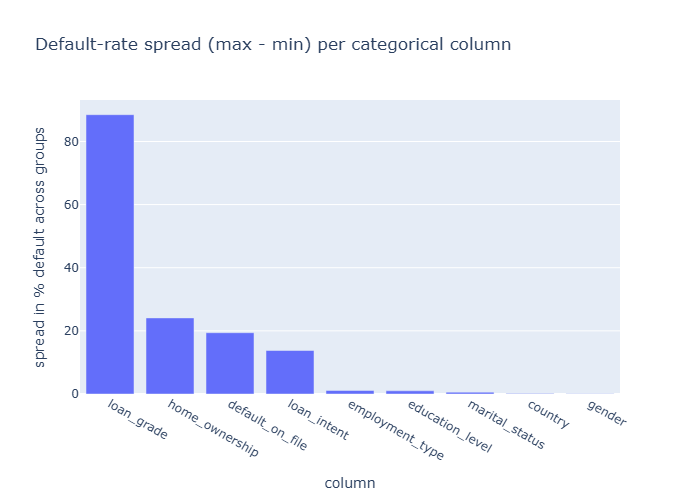

,column,n_groups,min_default_pct,max_default_pct,spread
0,loan_grade,7,9.96,98.44,88.48
1,home_ownership,4,7.47,31.57,24.10
2,default_on_file,2,18.39,37.81,19.41
3,loan_intent,6,14.81,28.59,13.78
4,employment_type,4,21.57,22.67,1.10
5,education_level,4,21.16,22.17,1.01
6,marital_status,4,21.37,21.96,0.59
7,country,3,21.73,21.86,0.13
8,gender,2,21.76,21.87,0.11


In [7]:
# Column lists derived from dtype, NOT hardcoded. A hardcoded list silently skips any
# column added to ml_features later - which is exactly what happened when the view grew
# from 18 to 25 columns and the original 5-column list kept scanning only the old ones.
# Pulling ID/target names from model.features keeps this scan aligned with the exact
# feature set the model will see.
import sys
sys.path.insert(0, '..')
from model.features import ID_COLS, TARGET_COL

feature_cols = [c for c in df.columns if c not in ID_COLS and c != TARGET_COL]
categorical_cols = [c for c in feature_cols if not pd.api.types.is_numeric_dtype(df[c])]
numeric_cols = [c for c in feature_cols if pd.api.types.is_numeric_dtype(df[c])]

print(f"scanning {len(feature_cols)} feature columns "
      f"({len(categorical_cols)} categorical + {len(numeric_cols)} numeric)")
print("categorical:", categorical_cols)
print("numeric    :", numeric_cols)

separation_scan = []
for col in categorical_cols:
    rates = df.groupby(col)[TARGET_COL].mean() * 100
    separation_scan.append({
        'column': col,
        'n_groups': rates.shape[0],
        'min_default_pct': round(rates.min(), 2),
        'max_default_pct': round(rates.max(), 2),
        'spread': round(rates.max() - rates.min(), 2),
    })

separation_df = pd.DataFrame(separation_scan).sort_values('spread', ascending=False).reset_index(drop=True)

fig_separation = px.bar(
    separation_df, x='column', y='spread',
    title='Default-rate spread (max - min) per categorical column',
    labels={'spread': 'spread in % default across groups'},
)
fig_separation.show()
separation_df

In [8]:
# Same dtype-derived lists, so every numeric x categorical pair gets checked - not just
# the 6 numeric columns the original hardcoded version happened to list.
variance_scan = []
for cat_col in categorical_cols:
    for num_col in numeric_cols:
        overall_var = df[num_col].var()
        within_group_var = df.groupby(cat_col)[num_col].var().mean()
        ratio = within_group_var / overall_var if overall_var else float('nan')
        variance_scan.append({
            'categorical': cat_col, 'numeric': num_col,
            'within_group_var_ratio': round(ratio, 4),
        })

variance_df = pd.DataFrame(variance_scan).sort_values('within_group_var_ratio').reset_index(drop=True)
print(f"{len(variance_df)} pairs checked; 10 most deterministic (lowest ratio = most suspicious):")
variance_df.head(10)

117 pairs checked; 10 most deterministic (lowest ratio = most suspicious):


,categorical,numeric,within_group_var_ratio
0,loan_grade,loan_int_rate,0.3930
1,default_on_file,loan_int_rate,0.6240
2,marital_status,income,0.8261
3,marital_status,other_debt,0.8964
4,loan_grade,income,0.8994
5,home_ownership,loan_int_rate,0.9098
6,default_on_file,other_debt,0.9100
7,default_on_file,income,0.9405
8,home_ownership,open_accounts,0.9646
9,home_ownership,loan_amnt,0.9668


### Third check: numeric columns vs. the target directly

The two scans above leave a gap. The separation scan only covers *categorical* columns,
and the variance-ratio scan compares numeric columns to *categorical* ones - neither tests
a numeric column against `loan_status` directly. That leaves 13 of 22 features unchecked
against the target.

Single-feature ROC-AUC closes it: train nothing, just rank by the raw column value and
measure how well that alone separates defaults. ~0.5 means no signal; approaching 1.0 (or
0.0, i.e. perfectly inverted) means the column nearly determines the outcome on its own,
which for an at-application feature means leakage.

In [9]:
from sklearn.metrics import roc_auc_score

numeric_auc = []
for col in numeric_cols:
    series = df[col]
    if series.notna().sum() == 0 or series.nunique() < 2:
        continue
    auc = roc_auc_score(df[TARGET_COL], series)
    numeric_auc.append({
        'column': col,
        'single_feature_auc': round(auc, 4),
        # distance from 0.5 works in both directions - an inverted predictor is just as
        # strong a signal as a direct one
        'separation_strength': round(abs(auc - 0.5), 4),
    })

numeric_auc_df = (pd.DataFrame(numeric_auc)
                  .sort_values('separation_strength', ascending=False)
                  .reset_index(drop=True))
print("single-feature ROC-AUC per numeric column (0.5 = pure noise):")
numeric_auc_df

single-feature ROC-AUC per numeric column (0.5 = pure noise):


,column,single_feature_auc,separation_strength
0,loan_percent_income,0.7208,0.2208
1,loan_int_rate,0.7081,0.2081
2,debt_to_income_ratio,0.6983,0.1983
3,income,0.3098,0.1902
4,other_debt,0.3576,0.1424
5,emp_length,0.4333,0.0667
6,loan_amnt,0.5587,0.0587
7,age,0.4769,0.0231
8,cred_hist_length,0.4835,0.0165
9,loan_term_months,0.5074,0.0074


**Domain question for whatever column tops either scan**: is this value known *at the
moment* a customer submits an application, or does the system only produce it *after* a
decision process (underwriting/risk scoring)? That's not something the data itself can
answer — it has to be reasoned about column by column.

`loan_grade` tops the separation scan by a wide margin: an 88.5-point spread (9.96% →
98.44%), vs. 24.1 for the next-highest column (`home_ownership`) and near-zero for
`country` — an order of magnitude beyond anything a normal risk factor produces.
`loan_grade` → `loan_int_rate` also has the lowest within-group variance ratio (0.39,
vs. 0.62 for the next-lowest pair): grouping by grade cuts `loan_int_rate`'s variance by
more than half, again the clear outlier rather than a marginal one. Both `loan_grade`
and `loan_int_rate` are underwriting outputs, not application-time inputs — that's what
turns "statistically the biggest outlier" into "actually leakage." Detail on those two
specifically follows.

## `loan_grade` / `loan_int_rate` vs. `loan_status` — leakage check

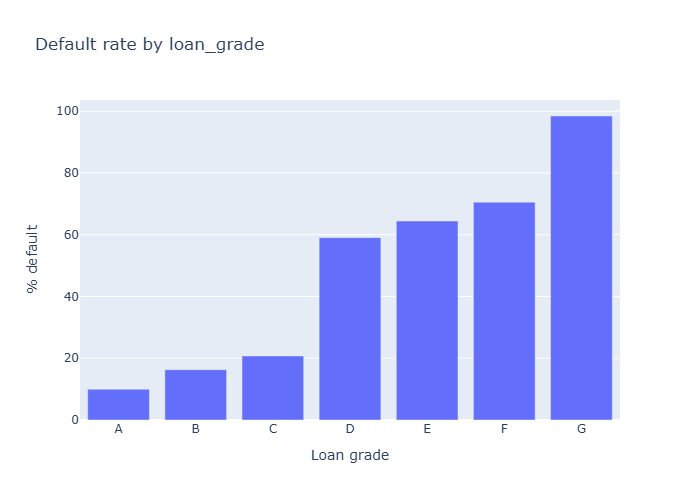

,loan_grade,default_rate_pct
0,A,9.96
1,B,16.28
2,C,20.73
3,D,59.05
4,E,64.42
5,F,70.54
6,G,98.44


In [10]:
default_by_grade = (df.groupby('loan_grade')['loan_status'].mean() * 100).round(2).sort_index()
default_by_grade = default_by_grade.reset_index(name='default_rate_pct')

fig_default_grade = px.bar(
    default_by_grade, x='loan_grade', y='default_rate_pct',
    title='Default rate by loan_grade',
    labels={'default_rate_pct': '% default', 'loan_grade': 'Loan grade'},
)
fig_default_grade.show()
default_by_grade

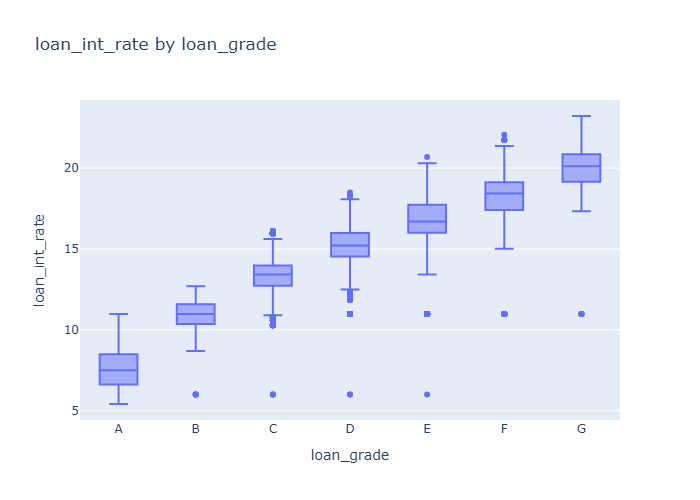

In [11]:
fig_rate_by_grade = px.box(
    df, x='loan_grade', y='loan_int_rate',
    category_orders={'loan_grade': sorted(df['loan_grade'].unique())},
    title='loan_int_rate by loan_grade',
)
fig_rate_by_grade.show()

### Decision: what goes into the at-application feature set

#### 1. Leakage — exclude `loan_grade` and `loan_int_rate`

Default rate by grade: **A=9.96%, B=16.28%, C=20.73%, D=59.05%, E=64.42%, F=70.54%,
G=98.44%** — a near-monotonic climb with near-total separation, 88.5-point spread vs.
24.1 for the next-highest column. `loan_grade` → `loan_int_rate` also has the lowest
within-group variance ratio of all 117 pairs checked (0.3930, vs. 0.6240 next). Both are
*outputs* of underwriting, not information available when a customer submits an
application — using them as input is leakage.

**Decision**: the *at-application* model drops both. The *portfolio* model may keep them,
since it isn't making an approval decision.

#### 2. No leakage found anywhere else

Running all three scans over the full 22-column feature set (not the 5 columns the
original hardcoded version checked) found **no other leakage**. Nothing among the newer
columns comes close to the extremes: no numeric column's single-feature AUC approaches
1.0 or 0.0, and no categorical spread approaches 0%/100%. The highest legitimate
signal is `loan_percent_income` (AUC 0.7208) — strong, but the kind of strength a real
risk factor has, not the kind leakage has.

#### 3. Most of the augmented columns carry no signal at all

Worth recording, because it changes what the model can honestly claim. Against a base
rate of ~21.8%, these columns barely move the needle:

| Column | Measure | Value |
|---|---|---|
| `past_delinquencies` | single-feature AUC | 0.5004 |
| `open_accounts` | single-feature AUC | 0.4980 |
| `credit_utilization_ratio` | single-feature AUC | 0.5051 |
| `loan_term_months` | single-feature AUC | 0.5074 |
| `gender` | default-rate spread | 0.11 pp |
| `country` | default-rate spread | 0.13 pp |
| `marital_status` | default-rate spread | 0.59 pp |
| `education_level` | default-rate spread | 1.01 pp |
| `employment_type` | default-rate spread | 1.10 pp |

An AUC of 0.5004 is indistinguishable from a coin flip. That is a striking result for
`past_delinquencies`, `credit_utilization_ratio` and `open_accounts` specifically: in a
real credit-bureau file these are among the *strongest* predictors of default. Finding
them at chance level is strong evidence they were synthetically generated independently
of `loan_status`, rather than being real bureau data. Same conclusion for the four
demographic columns.

This is good news for leakage (independent generation cannot leak the target) and bad
news for model quality — roughly 9 of 22 features are noise. It also means any SHAP
importance these columns pick up in session 12 is fitting randomness, and should be
read as such.

#### 4. Exclude `gender` and `marital_status` outright — fair lending

Separate from predictive value: `gender` and `marital_status` are **protected attributes**
in consumer credit decisions. In the US, ECOA / Regulation B prohibits using them as a
basis for a credit decision; Canada and the UK (the other two countries in this dataset)
have equivalent rules. A model that takes them as input is a compliance problem no matter
how it performs.

Here the decision is free: both are already statistically noise (0.11 pp and 0.59 pp
spread), so excluding them costs no accuracy. They're dropped from **both** feature sets —
including the portfolio model, since fair-lending exposure doesn't disappear just because
the model is analysing an existing book rather than approving a new application.

`country` is kept: geography is a legitimate portfolio-segmentation dimension and is used
by the session 15-16 dashboard, though at 0.13 pp spread it carries no predictive signal
either.

## Cross-check: `person_age` / `person_emp_length` outliers

Already blocked at ETL time (`historical_load.py::clean_outliers`) — this just confirms
nothing slipped through into Postgres.

In [12]:
print("age > 100:", (df['age'] > 100).sum())
print("age range:", df['age'].min(), "-", df['age'].max())
print("emp_length > age - 14 violations:", (df['emp_length'] > (df['age'] - 14)).sum())

age > 100: 0
age range: 20 - 94
emp_length > age - 14 violations: 0


## Distributions before vs. after median imputation

Raw = source file with missing values dropped. Postgres = after
`historical_load.py::impute_missing` filled them with the column median.

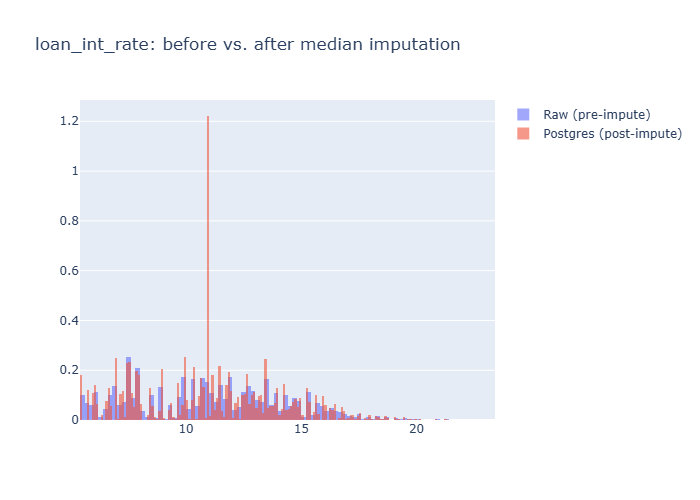

In [13]:
import plotly.graph_objects as go

fig_rate_compare = go.Figure()
fig_rate_compare.add_trace(go.Histogram(
    x=raw['loan_int_rate'].dropna(), name='Raw (pre-impute)',
    opacity=0.6, histnorm='probability density',
))
fig_rate_compare.add_trace(go.Histogram(
    x=df['loan_int_rate'], name='Postgres (post-impute)',
    opacity=0.6, histnorm='probability density',
))
fig_rate_compare.update_layout(
    barmode='overlay', title='loan_int_rate: before vs. after median imputation',
)
fig_rate_compare.show()

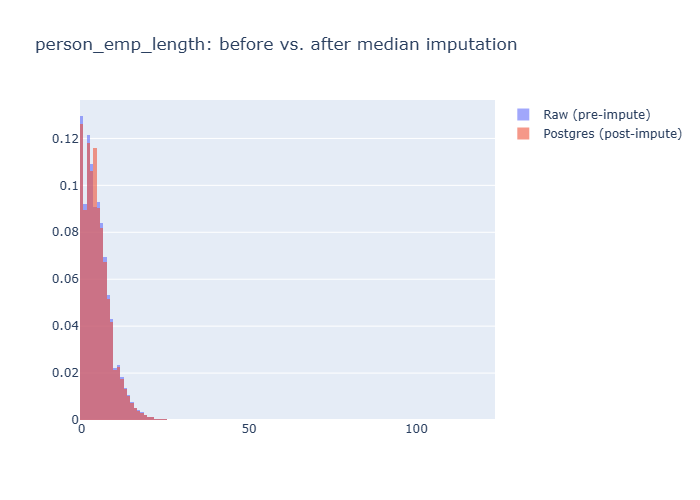

In [14]:
fig_emp_compare = go.Figure()
fig_emp_compare.add_trace(go.Histogram(
    x=raw['person_emp_length'].dropna(), name='Raw (pre-impute)',
    opacity=0.6, histnorm='probability density',
))
fig_emp_compare.add_trace(go.Histogram(
    x=df['emp_length'], name='Postgres (post-impute)',
    opacity=0.6, histnorm='probability density',
))
fig_emp_compare.update_layout(
    barmode='overlay', title='person_emp_length: before vs. after median imputation',
)
fig_emp_compare.show()

## Save key figures for the README

In [15]:
import os

os.makedirs('figures', exist_ok=True)
fig_status.write_image('figures/loan_status_distribution.png', scale=2)
fig_default_grade.write_image('figures/default_rate_by_grade.png', scale=2)
fig_rate_by_grade.write_image('figures/loan_int_rate_by_grade.png', scale=2)
print("Saved figures to notebooks/figures/")

Saved figures to notebooks/figures/
